In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages

In [2]:
model = ChatOllama(model = "qwen2.5:3b")

In [3]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [4]:
def chatbot(state: ChatState):
    messages = state['messages']
    response = model.invoke(messages)
    return {'messages': [response]}

In [5]:
graph = StateGraph(ChatState)

graph.add_node('ChatNode', chatbot)

graph.add_edge(START, 'ChatNode')
graph.add_edge('ChatNode', END)

workflow = graph.compile()

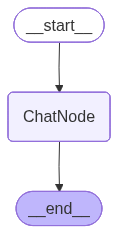

In [6]:
workflow

In [7]:
initial_state = {'messages': [HumanMessage(content='What is the capital of india')]}
final_state = workflow.invoke(initial_state)

In [8]:
final_state

{'messages': [HumanMessage(content='What is the capital of india', additional_kwargs={}, response_metadata={}, id='97e6bcd3-0ad9-4afa-aa9b-4cad57ce7e6f'),
  AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={'model': 'qwen2.5:3b', 'created_at': '2026-07-06T07:05:59.336311Z', 'done': True, 'done_reason': 'stop', 'total_duration': 502504208, 'load_duration': 209659833, 'prompt_eval_count': 1, 'prompt_eval_duration': 62016000, 'eval_count': 9, 'eval_duration': 227221000, 'logprobs': None, 'model_name': 'qwen2.5:3b', 'model_provider': 'ollama'}, id='lc_run--019f363f-7f2e-7940-a9a7-f7bcc4408253-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1, 'output_tokens': 9, 'total_tokens': 10})]}

In [10]:
final_state['messages']

[HumanMessage(content='What is the capital of india', additional_kwargs={}, response_metadata={}, id='97e6bcd3-0ad9-4afa-aa9b-4cad57ce7e6f'),
 AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={'model': 'qwen2.5:3b', 'created_at': '2026-07-06T07:05:59.336311Z', 'done': True, 'done_reason': 'stop', 'total_duration': 502504208, 'load_duration': 209659833, 'prompt_eval_count': 1, 'prompt_eval_duration': 62016000, 'eval_count': 9, 'eval_duration': 227221000, 'logprobs': None, 'model_name': 'qwen2.5:3b', 'model_provider': 'ollama'}, id='lc_run--019f363f-7f2e-7940-a9a7-f7bcc4408253-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1, 'output_tokens': 9, 'total_tokens': 10})]

In [11]:
final_state['messages'][-1]

AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={'model': 'qwen2.5:3b', 'created_at': '2026-07-06T07:05:59.336311Z', 'done': True, 'done_reason': 'stop', 'total_duration': 502504208, 'load_duration': 209659833, 'prompt_eval_count': 1, 'prompt_eval_duration': 62016000, 'eval_count': 9, 'eval_duration': 227221000, 'logprobs': None, 'model_name': 'qwen2.5:3b', 'model_provider': 'ollama'}, id='lc_run--019f363f-7f2e-7940-a9a7-f7bcc4408253-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1, 'output_tokens': 9, 'total_tokens': 10})

In [12]:
final_state['messages'][-1].content

'The capital of India is New Delhi.'

In [15]:
while True:
    user_query = input('Enter your prompt: ')
    if user_query.strip().lower() in ['exit', 'bye', 'quit']:
        break
    response = workflow.invoke({'messages': [HumanMessage (content = user_query)]})
    print('AI: ', response['messages'][-1].content)

AI:  Hello! How can I assist you today?
AI:  Artificial Intelligence (AI) refers to the simulation of human intelligence processes by machines, especially computer systems. These processes include learning (the acquisition of information and rules for using the information), reasoning (using the rules to reach approximate or definite conclusions), and self-correction.

There are various types of AI technologies:

1. **Machine Learning**: This involves training algorithms to identify patterns in data without being explicitly programmed. It's a subset of AI that allows software applications to grow more accurate at predicting outcomes or classifying things as they process larger amounts of data over time.

2. **Deep Learning**: A type of machine learning where algorithms are structured like the human brain’s neural networks, enabling them to recognize complex patterns and inputs from data such as images, speech, and text.

3. **Natural Language Processing (NLP)**: This technology allows 